# LDOS DAY 3: KNNS and Fine Tuning

Yesterday, we tested a baseline **Perceptron's** ability to perform a prediction on LDOS' RAID 1 dataset. Today we're testing a second model, **KNN**, learning to engineer new features for both speed and accuracy, and oppening the floor for a headstart on our ML for Systems Challenge.

## Respond Here: Double-click on this cell and add your names below.

Team Member Names: Yi Lang and Surya

Group #: 28

Team Name: Jupyter Moon

# Loading Libraries

In this notebook, we’ll use:

- *polars* for working with dataframes
- *matplotlib* and *seaborn* for creating charts and graphs
- *sklearn* for our models
- *numpy* for data normalization

We'll load them in the next code cell. Click on the play button next to the cell to run just the cell below.

In [2]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sklearn

# Model and metric imports
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Custom method imports
from library import process_block_io_flags, time_model_execution

# Recap: Loading our Data

Same as yesterday, we're loading a single file of our RAID 1 database.

In [3]:
df_read = pl.read_parquet('1.parquet')
print(df_read.columns)

['cpu', 'device', 'sector', 'segments', 'block_io_bytes', 'ts_uptime_us', 'block_io_flags', 'queue_length_segment_ios', 'queue_length_4k_ios', 'collection_id', 'finish_ts_uptime_us', 'block_latency_us', 'block_io_latency_us', 'measured_latency_us', 'block_io_flags_string', 'label85', 'label90', 'label95']


# Feature Engineering

This whole week, we've been working with *features*, raw data transformed into an input variables usable by models. A large part of both training and optimizing a model, however, is how you engineer your features to produce the best possible output. Lets start by *adding* a feature.

We're going to build `last_latency_block_io_us`, a feature telling us, for each read request we receive, what was the latency of the most recently **finished** read on that same device?

We choose to do this with `join_asof`, which iterates backwards on a sorted dataframe to find, for every row, the most recent matching row that happened before it in time. The reason we want to highlight this is that the naive "loop over every pair of rows" approach would be O(N²), making it far too slow for a dataset with millions of rows (~1,159,000,000,000 operations).


In [4]:
import warnings

# Only finished I/Os have a real latency we can "look back" at
df_finished = df_read.filter(
    pl.col("finish_ts_uptime_us").is_not_null()
).select([
    "device",
    "ts_uptime_us",
    pl.col("block_io_latency_us").alias("last_latency_block_io_us"),
])

# Sort our dataframe by ts_uptime_us
df_read_sorted = df_read.sort("ts_uptime_us")
df_finished_sorted = df_finished.sort("ts_uptime_us")

# For each row, find the most recently finished read on the same device
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    df_with_history = df_read_sorted.join_asof(
        df_finished_sorted,
        on="ts_uptime_us",
        by="device",
        strategy="backward",
    )

# Display our new feature
display(df_with_history.select(
    ["device", "ts_uptime_us", "last_latency_block_io_us"]
).head())

device,ts_uptime_us,last_latency_block_io_us
i64,i64,i64
271581186,406416557135,8534
271581185,406416557190,8498
271581186,406416557219,8459
271581184,406416557247,9328
271581185,406416557269,8679


# Respond Here: History Feature

1. Why can we only use data from a read thats *already finished* when we're building this feature? We have access to data about reads that haven't finished yet, what might happen if we "peeked" ahead?

If we peeked ahead, then data leakage would occur since the model has trained on the data it is testing to predict, so its accuracy will be high since its already seen it before, it is likely to have overfitted.

2. There's an edge case when accessing the latency of the last *finished* read on a device, what is it? While we handle this case for you in a later cell, what would happen if we didn't?

The edge case when accessing latency is when the latency reads as a null value, but if we didn't handle this, the code would likely run into an error due to a type mismatch.



# Training our Model

We're going to go through the same processing as Module 2,but starting from `df_with_history` so that our new feature persists.

In [5]:
# Drop columns that represent future information or unused target labels
df_drop = df_with_history.drop([
    'collection_id', 'block_io_latency_us', 'block_latency_us',
    'measured_latency_us', 'label85', 'label95', 'finish_ts_uptime_us'
])

# Seperate flags into discrete columns
df = process_block_io_flags(df_drop)

# Only keep 'Read' operations
df_reads = df.filter(pl.col('Read'))

# Handle the the "no previous read yet" rows with median latency
median_latency = df_reads["last_latency_block_io_us"].median()
df_reads = df_reads.with_columns(
    pl.col("last_latency_block_io_us").fill_null(median_latency)
)

# Respond Here: Handling Edge Cases

1. Why might filtering with 0 be a bad idea here?

Filtering with 0, (replacing null values) for 0 is a bad idea since it will skew the values, since in a dataset filled with false values, it will cause a false decrease in values.

2. Can you think of another value that might make sense?

Filling with the median, as shown above, is a good way to combat both noise (arising from very large/small values) and allows the data to not be skewed and still be representative.


# Test/Train Split

Back to the same process as Module 2.

In [6]:
# Add a row index column to the DataFrame
df_reads_indexed = df_reads.with_row_index()

# Split the data into training and testing sets (80-20 split)
train_df = df_reads_indexed.sample(fraction=0.8, with_replacement=False, seed=42)
test_df = df_reads_indexed.join(train_df.select('index'), on='index', how='anti')

# Drop the index column from the split dataframes
train_df = train_df.drop('index')
test_df = test_df.drop('index')

# Confirm our split
print("Training data shape:", train_df.shape)
print("Testing data shape:", test_df.shape)

Training data shape: (63269, 16)
Testing data shape: (15818, 16)


In [7]:
from scipy.stats import norm

# Seperate our target
train_target_np = train_df['label90'].to_numpy()
test_target_np = test_df['label90'].to_numpy()

# Two versions of the features: with and without our new history feature
train_features_full = train_df.drop('label90')
test_features_full = test_df.drop('label90')

train_features_baseline = train_features_full.drop('last_latency_block_io_us')
test_features_baseline = test_features_full.drop('last_latency_block_io_us')

# Convert training sets into NumPy arrays
train_full_np = train_features_full.to_numpy()
test_full_np = test_features_full.to_numpy()

train_baseline_np = train_features_baseline.to_numpy()
test_baseline_np = test_features_baseline.to_numpy()

# Normalize our data with history
norm_np = np.abs(train_full_np).max(axis=0) + 0.0001
train_full_np = train_full_np / norm_np
test_full_np = test_full_np / norm_np

# Normalize our data without history
norm_np = np.abs(train_baseline_np).max(axis=0) + 0.0001
train_baseline_np = train_baseline_np / norm_np
test_baseline_np = test_baseline_np / norm_np

# A Reusable Evaluation Function

It seems a little silly to be copy/pasting the same five-line "calculate accuracy, precision,recall, F1, confusion matrix, and timing" block over and over. Today, lets write a helper function so we can reuse it for every model and feature set we try.

In software engineering, this is called *code refactoring*, and is key to developing clean, usable code.

In [8]:
# Calculate accuracy and speed evaluation metrics
def evaluate_model(name, model, features_np, target_np):
    predictions = model.predict(features_np)

    accuracy = accuracy_score(target_np, predictions)
    precision = precision_score(target_np, predictions)
    recall = recall_score(target_np, predictions)
    f1 = f1_score(target_np, predictions)
    conf_matrix = confusion_matrix(target_np, predictions)
    ts_ns = time_model_execution(model, features_np)

    print()
    print(f"--- {name} ---")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"Time per prediction: {ts_ns:.2f}ns, {ts_ns/1000:.2f}us")
    print("Confusion Matrix:")
    print(conf_matrix)
    print()

    return {"name": name, "accuracy": accuracy, "f1": f1, "time_ns": ts_ns}

# We'll collect every model's results here for a final comparison
results = []

# Recap: Yesterday's Perceptron

Lets retrain yesterday's baseline Perceptron using the **baseline** feature set so we can have metrics to compare our KNN against

In [9]:
# Define the MLPClassifier model with no hidden layers
baseline_percept = MLPClassifier(hidden_layer_sizes=(), activation='relu', solver='adam', max_iter=500, random_state=42)

# Train the baseline Perceptron
baseline_percept.fit(train_baseline_np, train_target_np)

# Save our results
results.append(evaluate_model("Baseline Perceptron", baseline_percept, test_baseline_np, test_target_np))

Warming up the model with 10000 iterations...
Warm-up complete.
Timing single prediction in nanoseconds...

--- Baseline Perceptron ---
Accuracy:  0.8593
Precision: 0.8537
Recall:    0.9902
F1 Score:  0.9169
Time per prediction: 63.27ns, 0.06us
Confusion Matrix:
[[ 1320  2103]
 [  122 12273]]



# Introducing KNN

Now, lets train a **baseline** KNN for comparison

In [10]:
# Define the KNeighborsClassifier model with K = 5
baseline_knn = KNeighborsClassifier(n_neighbors=5)

# Train the baseline KNN
baseline_knn.fit(train_baseline_np, train_target_np)

# Save our results
results.append(evaluate_model("Baseline KNN, K=5", baseline_knn, test_baseline_np, test_target_np))

Warming up the model with 10000 iterations...
Warm-up complete.
Timing single prediction in nanoseconds...

--- Baseline KNN, K=5 ---
Accuracy:  0.8382
Precision: 0.8504
Recall:    0.9628
F1 Score:  0.9031
Time per prediction: 134986.14ns, 134.99us
Confusion Matrix:
[[ 1324  2099]
 [  461 11934]]



# Hyperparameter Tuning: Finding a Good K

Just like hidden layers and neurons, K is a "knob" we can turn. Lets try a few values and see how they do!

In [11]:
# Define our metrics
k_values = [1, 3, 5, 7, 9, 11, 15, 21, 31]
k_accuracies = []
k_f1_scores = []
k_times = []

# "Turn the knob", testing different k_values
for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(train_baseline_np, train_target_np)
    predictions = model.predict(test_baseline_np)

    k_accuracies.append(accuracy_score(test_target_np, predictions))
    k_f1_scores.append(f1_score(test_target_np, predictions))
    k_times.append(time_model_execution(model, test_baseline_np))

    print(f"k = {k}  accuracy = {k_accuracies[-1]:.4f}  f1 = {k_f1_scores[-1]:.4f}   speed = {k_times[-1]/1000:.2f}us")
    print()

Warming up the model with 10000 iterations...
Warm-up complete.
Timing single prediction in nanoseconds...
k = 1  accuracy = 0.7705  f1 = 0.8542   speed = 106.11us

Warming up the model with 10000 iterations...
Warm-up complete.
Timing single prediction in nanoseconds...
k = 3  accuracy = 0.8209  f1 = 0.8911   speed = 122.52us

Warming up the model with 10000 iterations...
Warm-up complete.
Timing single prediction in nanoseconds...
k = 5  accuracy = 0.8382  f1 = 0.9031   speed = 188.31us

Warming up the model with 10000 iterations...
Warm-up complete.
Timing single prediction in nanoseconds...
k = 7  accuracy = 0.8463  f1 = 0.9086   speed = 145.87us

Warming up the model with 10000 iterations...
Warm-up complete.
Timing single prediction in nanoseconds...
k = 9  accuracy = 0.8481  f1 = 0.9100   speed = 186.43us

Warming up the model with 10000 iterations...
Warm-up complete.
Timing single prediction in nanoseconds...
k = 11  accuracy = 0.8497  f1 = 0.9111   speed = 165.51us

Warming u

# Exploratory Data Analysis: KNN

Lets plot our hyperparameter tuning results to better understand our data

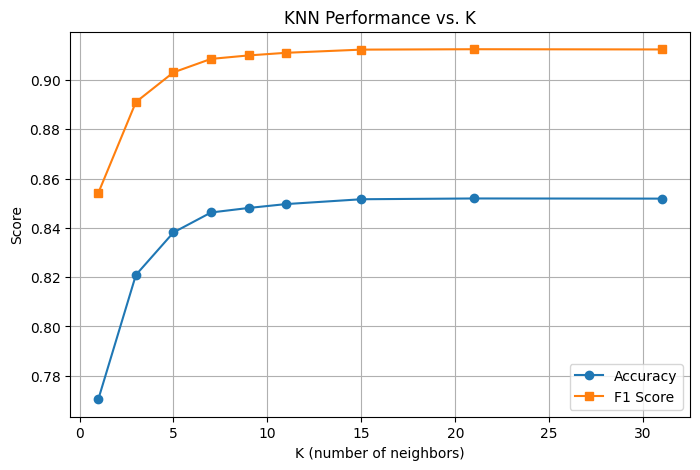

In [12]:
# Define an 8" x 5" subplot
fig, ax1 = plt.subplots(figsize=(8, 5))

# Plot the results of our tuning
ax1.plot(k_values, k_accuracies, marker='o', label='Accuracy')
ax1.plot(k_values, k_f1_scores, marker='s', label='F1 Score')

# Define our labels and title
ax1.set_xlabel('K (number of neighbors)')
ax1.set_ylabel('Score')
ax1.set_title('KNN Performance vs. K')
ax1.legend(loc='lower right')
ax1.grid(True)

# Display our plot
plt.show()

# Respond Here: Exploratory Data Analysis for KNN

1. Looking at your plot, how is accuracy and F1 when K=1? Why might a single neighbor be "risky?"

Accuracy and F1 when k=1 are both very low compared to the metrics when k increases, since a single neighbor is risky precisely because one neighbor is likely to not be completely representative of a category.

2. As a general rule, what happens to accuracy and F1 as K gets larger? What function does this look like it may map to (Linear, Quadratic, Logarithmic, Exponential, etc.)?

Generally, it looks like a logarithimic graph, since generally, it increase exponentially at the beginning and reaches a sort of asymptote.

3. Look back at our timing data (which is bound to be noisy due to runtime variance). Does prediction time generally trend faster or slow as we increase K?

Prediction time generally trends slower as we increase K.

4. Pick the K value your team believes is best and write it down, justifying your decision based on the score plot and timing data.

k = 11, since it is right before the asymptote and balances speed and accuracy.

In [13]:
# CHANGE THIS to your K value (hint: its probably not 1)
best_k = 11

# Does our Distance Metric Matter

The KNN classifier we've been using *Euclidean distance* as its distance metric, which is the distance between two points in Euclidean space (a coordinate system, think x, y, z). Our features, however, include varied scales (like binary classification for our `block_io_flags`).

We've provided you with a *Manhattan distance* test, but feel free to research and test any distance metric you'd like!

In [14]:
# Define the KNeighborsClassifier model with your chosen K and Manhattan distance
knn_manhattan = KNeighborsClassifier(n_neighbors=best_k, metric='manhattan')

# Train your Manhattan KNN
knn_manhattan.fit(train_baseline_np, train_target_np)

# Save our results
results.append(evaluate_model(f"Manhattan KNN, K={best_k}", knn_manhattan, test_baseline_np, test_target_np))

Warming up the model with 10000 iterations...
Warm-up complete.
Timing single prediction in nanoseconds...

--- Manhattan KNN, K=11 ---
Accuracy:  0.8519
Precision: 0.8491
Recall:    0.9862
F1 Score:  0.9125
Time per prediction: 274680.37ns, 274.68us
Confusion Matrix:
[[ 1251  2172]
 [  171 12224]]



# Respond Here: Distance Metrics

1. Did changing the distance metric help, hurt, or do nothing? Why do you think?

It hurt, it dramatically increased the time per perdiction for little gain in accuracy.

2. Brainstorm with your team: what's one thing you could do to the **data** that might make distance-based models work better? *Hint: Google "feature scaling"*.

Adjust based on min-maxs, standard deviation in the data as well.



# Does our History Feature Help?

Remember that history feature we added at the start of the notebook? Lets see if retraining our KNN using your chosen `best_k` and `last_latency_block_io_us` actually helps model performance compared to the baseline.

In [15]:
# Define the KNeighborsClassifier model with your chosen K and Manhattan distance
knn_with_history = KNeighborsClassifier(n_neighbors=best_k)

# Train your KNN with history
knn_with_history.fit(train_full_np, train_target_np)

# Save our results
results.append(evaluate_model(f"KNN with History, K={best_k}", knn_with_history, test_full_np, test_target_np))

Warming up the model with 10000 iterations...
Warm-up complete.
Timing single prediction in nanoseconds...

--- KNN with History, K=11 ---
Accuracy:  0.9050
Precision: 0.9016
Recall:    0.9864
F1 Score:  0.9421
Time per prediction: 202557.20ns, 202.56us
Confusion Matrix:
[[ 2089  1334]
 [  169 12226]]



# Respond Here: Adding Features

Compare your KNN with history to your `best_k` KNN result without history (you might need to re-run the previous cell with `metric='euclidean`)

1. Did adding in history through `last_latency_block_io_us` improve accuracy/F1?

Yes, each metric went up by a significant amount.

2. Did adding it significantly change prediction time? Why might or might not adding/subtracting a feature affect a model's speed?

It didn't change time per prediction by as much amount as the Manhattan distance did, though it did increase since adding a feature will decrease model speed as more calculations will be needed.

3. Why might adding/subtracting a feature affect a KNN's speed more than it would a Perceptron's?

Since the KNN has to plot the distance between points, adding a new feature adds a lot more points for the KNN to calculate, as a Perceptron would realisitcally only add one more calculation per epoch.

# EDA for Feature Selection

So... should we keep every feature? Well, as always, *it depends*, but lets look at the data ourselves

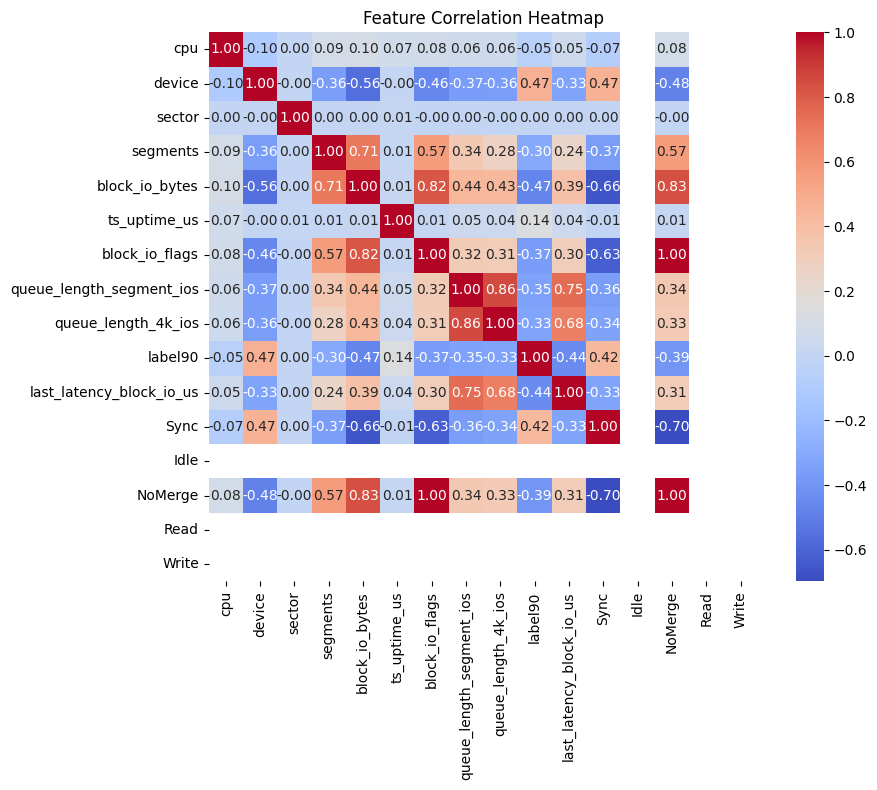

In [16]:
import seaborn as sns

# Correlation matrix/heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = df_reads.to_pandas().corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

# Respond Here: EDA for Feature Selection

1. Which features are most strongly correlated with `label90`, either positively or negatively?

device, block_io_bytes, last_latency_block_io_us, sync

2. Are there any other features strongly correlated with eachother? If so, could we drop one without losing much information?

queue_length_4k_ios and queue_length_ios -> basically same thing, yes you can drop it.

3. Does `last_latency_block_io_us` seem to be useful from what we've learned here? Does that match what we saw when we ran the model with the feature?

Not necessarily, since we can see that the model is generally correleating with other time metrics, this matches what we saw when we ran the model with the feature.

# Respond Here: Conclusions

1. List the pros/cons of using a Perceptron, based on what we've seen over the last two days.

A perceptron is very simple and fast, and serves as a very interpretiable model for understanding its decisions, but bad news is that they cannot handle complex problems with non simple patterns

2. List the pros/cons of using KNN, based on what we've seen over the last two days.

A KNN is generally also simple and can take new data since there is no training. Cons, it does worse with more features (distance issue) and can be computational slow because of the distance calcs.

3. Why or why not might we benefit from using a KNN over a Perceptron for this specific prediction task?

We may benefit if fewer features are needed for a prediction task since it will capture patterns better and take less time to run. We would use a perceptron for simple predictions since it is simple and extremely fast.

4. What decisions from the last two days were, in your opinion, best at optimizing the model's performance, be that accuracy or speed?

Optimizing the model's performance requires EDA to explore how the model performs with different parameters, and adjusting these values and running the model is a good way to see the general "cutoff" or balance between the two metrics.

# (Optional) Get Ahead on the ML for Systems Challenge

Now that we have a good bank of results from prior models, feel free to use the space below to use what you learned today and try some new models/tuning/features, this is your sandbox!

We'll still be working with a single parquet file of the 100 total we have for quick iteration, so focus on exploring *relative change* between your decisions rather than just getting the best numerical results you can.

In [ ]:
# from sklearn.linear_model import LogisticRegression
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.svm import SVC

# Uncomment and try one of these out, or add your own code to explore how your decisions impact performance
# new_model = LogisticRegression(max_iter=500)
# new_model.fit(train_features_np, train_target_np)
# results.append(evaluate_model(f"[Model Name]", new_model, test_full_np, test_target_np))

# View the results of all your model calls up to this point
# for result in results:
#     print(f"{result['name']}  accuracy = {result['accuracy']:.4f}  f1 = {result['f1']:.4f}   speed = {result['time_ns']/1000:.2f}us")

## Download and Turn in this notebook

Make sure you've run all the code cells and answered every "Respond Here" cell, then, download this notebook as "Group_[group number]_Module_3.ipynb" and submit at this link: https://forms.gle/DqHoLXgmav3H2k9d8